# Лабораторная 3. Временные ряды

Курс «Продвинутые методы оптимизации».

В этой работе я реализовал несколько методов фильтрации временных рядов,
сравнил их на данных о продажах из `sell.csv` и проанализировал данные своего
варианта.

Сам код фильтров и анализа я вынес в папку `src/`, а в ноутбуке оставил только
запуск и графики, чтобы не смешивать реализацию с экспериментами.

In [1]:
import sys
sys.path.append("src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (seed_everything, load_sell, get_variant_data, variant_from_isu,
                   PRODUCTS, mse, mae, snr_db, roughness, residual_std)
from filters import (moving_average, exponential_smoothing, kalman_filter,
                     savitzky_golay, lms_filter)
from analysis import (describe, autocorrelation, dominant_period, acf_period,
                      correlation_matrix, cross_correlation)

seed_everything(42)

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.3})

## Выбор варианта

Вариант считается по формуле из задания: сумма цифр номера ИСУ по модулю 60.
Свой номер я записал в переменную `ISU`.

In [2]:
ISU = 490030

VARIANT = variant_from_isu(ISU)
print(f"ИСУ = {ISU}  ->  вариант {VARIANT}")

ИСУ = 490030  ->  вариант 16


In [3]:
df = load_sell("sell.csv")
data = get_variant_data(df, VARIANT)
days = data.index.values
print("Размер данных варианта:", data.shape)
data.head()

Размер данных варианта: (50, 6)


,мыло,порошок,средство,краска,пена,прибыль
day,,,,,,
1,82.0,17.0,15.0,46.0,23.0,27.284
2,126.0,19.0,22.0,42.0,14.0,29.160
3,102.0,11.0,18.0,42.0,21.0,28.534
4,84.0,21.0,23.0,41.0,19.0,23.373
5,89.0,25.0,24.0,42.0,20.0,25.534


Сначала посмотрел, как выглядят все шесть рядов варианта.

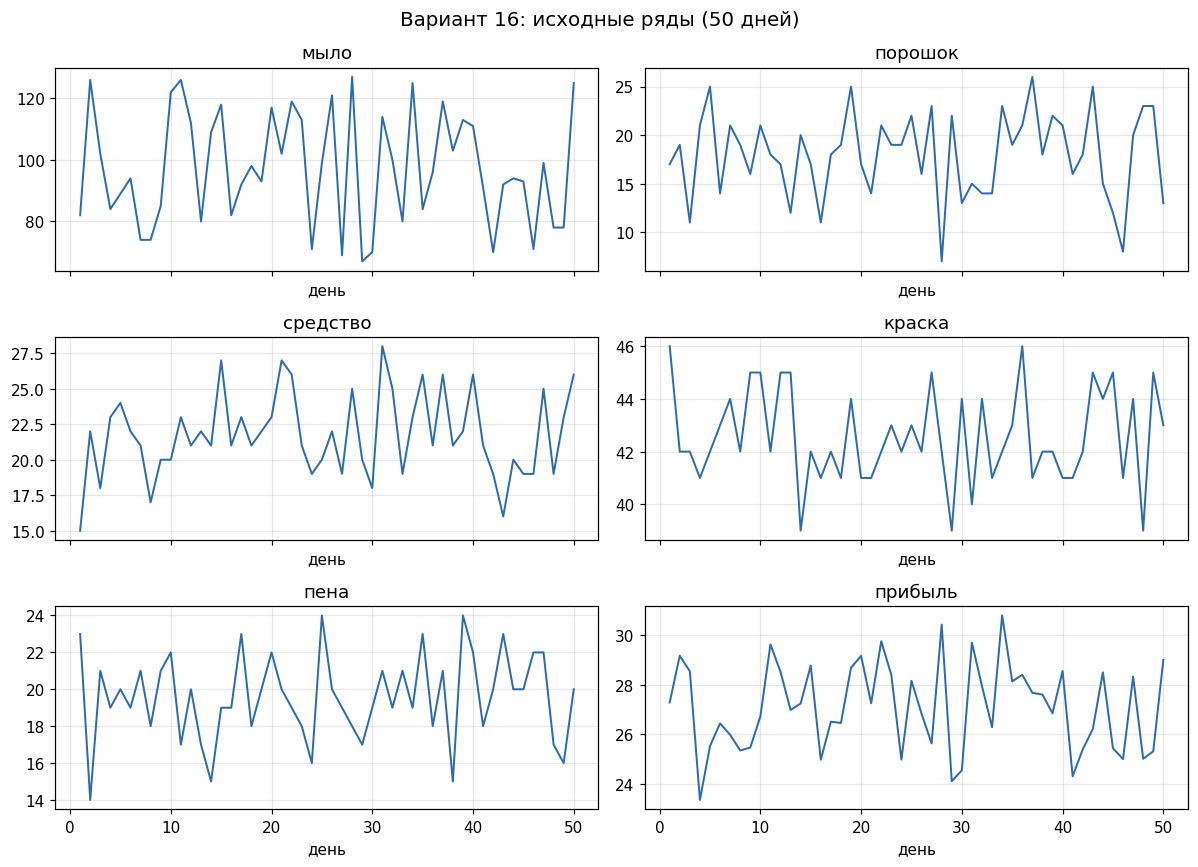

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(11, 8), sharex=True)
for ax, prod in zip(axes.ravel(), PRODUCTS):
    ax.plot(days, data[prod].values, color="#2b6cb0", lw=1.3)
    ax.set_title(prod); ax.set_xlabel("день")
fig.suptitle(f"Вариант {VARIANT}: исходные ряды (50 дней)", fontsize=13)
fig.tight_layout(); plt.show()

Видно, что ряды товаров скачут вокруг какого-то среднего уровня, а прибыль
заметно более гладкая. Дальше я работаю с одним рядом («мыло»), к остальным
методы применяются точно так же.

In [5]:
TARGET = "мыло"
x = data[TARGET].values
desc = describe(x)
for k, v in desc.items():
    print(f"{k}: {v:.3f}")

mean: 97.060
std: 18.414
min: 67.000
max: 127.000
trend_slope: -0.081


## Задача 1. Реализация фильтров

### Скользящее среднее и экспоненциальное сглаживание

Скользящее среднее усредняет точку с соседями в окне. Экспоненциальное
сглаживание тоже усредняет, но свежие значения берёт с большим весом, а старые
постепенно забывает (за это отвечает параметр alpha).

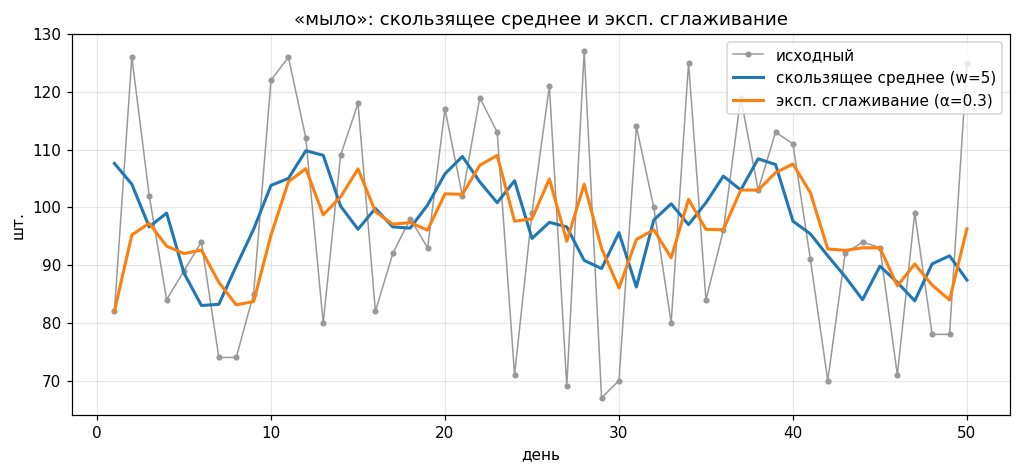

In [6]:
ma = moving_average(x, window=5, center=True)
es = exponential_smoothing(x, alpha=0.3)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(days, x, color="0.6", marker="o", ms=3, lw=1, label="исходный")
ax.plot(days, ma, lw=2, label="скользящее среднее (w=5)")
ax.plot(days, es, lw=2, label="эксп. сглаживание (α=0.3)")
ax.set_xlabel("день"); ax.set_ylabel("шт."); ax.legend()
ax.set_title(f"«{TARGET}»: скользящее среднее и эксп. сглаживание")
plt.show()

### Фильтр Калмана

Я взял самый простой вариант — модель локального уровня (случайное блуждание).
Фильтр считает, что есть истинный уровень, который медленно меняется, а
измерения зашумлены. На каждом шаге он смешивает своё предсказание с новым
измерением. Отношение шума процесса q к шуму измерения r задаёт, насколько
сильно сглаживать: чем меньше q, тем глаже результат.

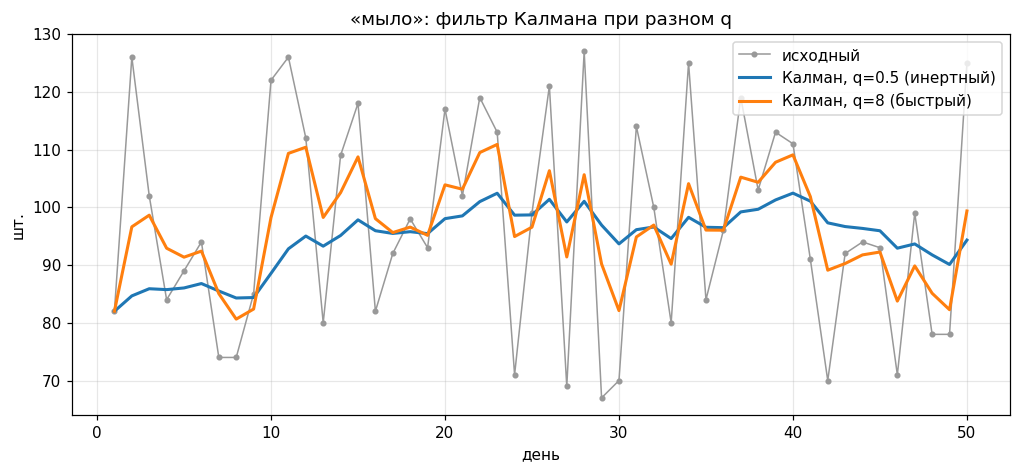

In [7]:
kf_strong = kalman_filter(x, q=0.5, r=30.0)
kf_soft = kalman_filter(x, q=8.0, r=30.0)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(days, x, color="0.6", marker="o", ms=3, lw=1, label="исходный")
ax.plot(days, kf_strong, lw=2, label="Калман, q=0.5 (инертный)")
ax.plot(days, kf_soft, lw=2, label="Калман, q=8 (быстрый)")
ax.set_xlabel("день"); ax.set_ylabel("шт."); ax.legend()
ax.set_title(f"«{TARGET}»: фильтр Калмана при разном q")
plt.show()

### Фильтр Савицкого-Голея

Здесь в каждом окне строится полином методом наименьших квадратов, и берётся
его значение в центре окна. По сравнению со скользящим средним он лучше
сохраняет форму и высоту пиков, а не размазывает их. Правильность реализации я
проверил сравнением со `scipy.signal.savgol_filter` — во внутренней области
совпадает.

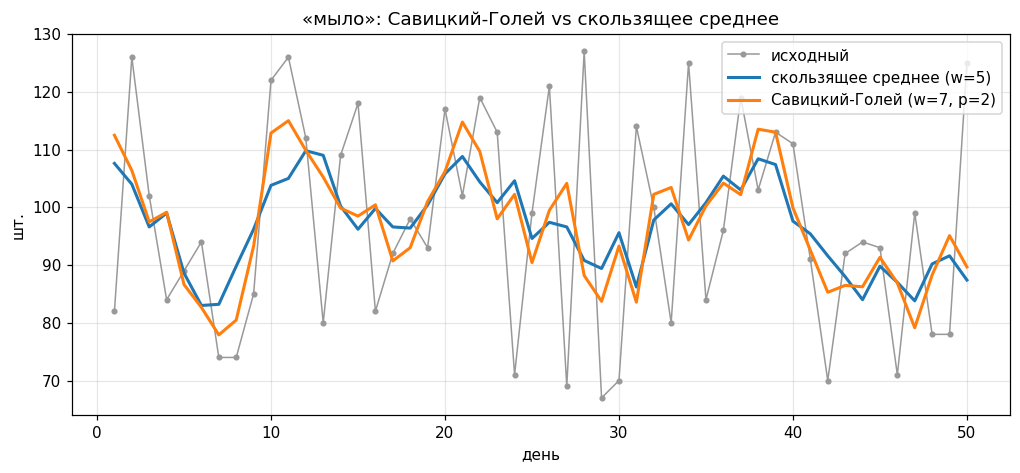

In [8]:
sg = savitzky_golay(x, window=7, poly_order=2)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(days, x, color="0.6", marker="o", ms=3, lw=1, label="исходный")
ax.plot(days, ma, lw=2, label="скользящее среднее (w=5)")
ax.plot(days, sg, lw=2, label="Савицкий-Голей (w=7, p=2)")
ax.set_xlabel("день"); ax.set_ylabel("шт."); ax.legend()
ax.set_title(f"«{TARGET}»: Савицкий-Голей vs скользящее среднее")
plt.show()

### Адаптивный фильтр LMS (хард-часть)

В отличие от остальных, у этого фильтра коэффициенты не фиксированы — он
подстраивает их на каждом шаге, чтобы уменьшить ошибку предсказания (по сути
градиентный спуск в реальном времени). Я использовал его в режиме предсказания:
он предсказывает текущий день по нескольким предыдущим. Плавная часть сигнала
попадает в выход, а шум остаётся в ошибке. Чтобы фильтр быстрее сходился, перед
работой я вычитаю среднее (у продаж большое постоянное смещение).

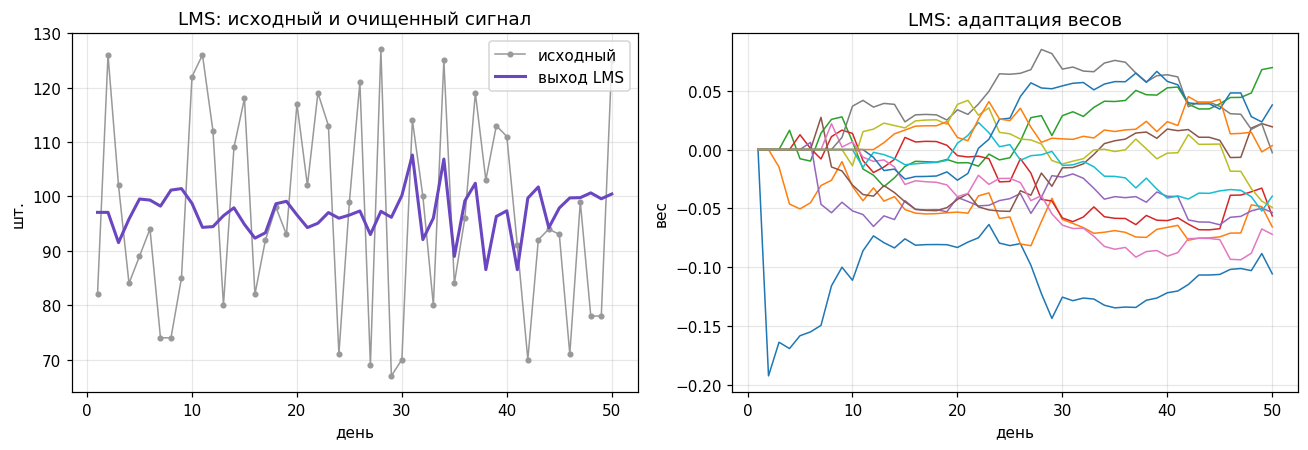

In [9]:
lms_y, lms_e, lms_w = lms_filter(x, n_taps=12, mu=0.1, delay=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(days, x, color="0.6", marker="o", ms=3, lw=1, label="исходный")
axes[0].plot(days, lms_y, lw=2, color="#6b46c1", label="выход LMS")
axes[0].set_xlabel("день"); axes[0].set_ylabel("шт."); axes[0].legend()
axes[0].set_title("LMS: исходный и очищенный сигнал")

for k in range(lms_w.shape[1]):
    axes[1].plot(days, lms_w[:, k], lw=1)
axes[1].set_xlabel("день"); axes[1].set_ylabel("вес")
axes[1].set_title("LMS: адаптация весов")
fig.tight_layout(); plt.show()

## Задача 2. Сравнение методов на данных варианта

Свёл все пять фильтров на один график.

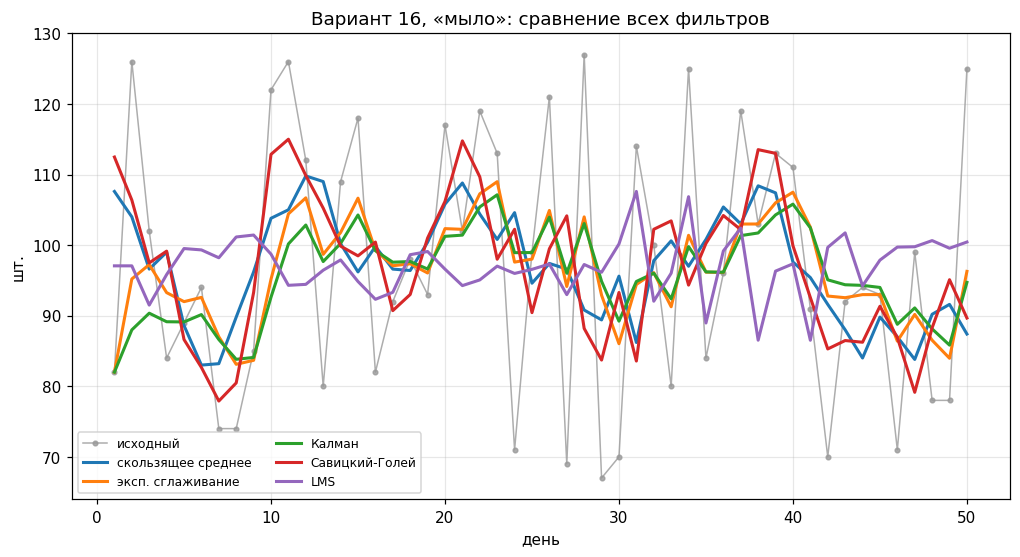

In [10]:
kf = kalman_filter(x, q=2.0, r=30.0)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(days, x, color="0.6", marker="o", ms=3, lw=1, label="исходный", alpha=0.8)
ax.plot(days, ma, lw=2, label="скользящее среднее")
ax.plot(days, es, lw=2, label="эксп. сглаживание")
ax.plot(days, kf, lw=2, label="Калман")
ax.plot(days, sg, lw=2, label="Савицкий-Голей")
ax.plot(days, lms_y, lw=2, label="LMS")
ax.set_xlabel("день"); ax.set_ylabel("шт."); ax.legend(ncol=2, fontsize=8)
ax.set_title(f"Вариант {VARIANT}, «{TARGET}»: сравнение всех фильтров")
plt.show()

У реальных данных нет «чистого» сигнала, поэтому качество я оценил косвенно:
roughness — насколько ряд дёрганый (меньше = глаже), resid_std — разброс того,
что фильтр убрал.

In [11]:
rows = [("исходный", roughness(x), 0.0)]
for nm, f in [("скольз. среднее", ma), ("эксп. сглаж.", es), ("Калман", kf),
              ("Савицкий-Голей", sg), ("LMS", lms_y)]:
    rows.append((nm, roughness(f), residual_std(x, f)))
pd.DataFrame(rows, columns=["фильтр", "roughness", "resid_std"]).round(2)

,фильтр,roughness,resid_std
0,исходный,1985.65,0.00
1,скольз. среднее,56.86,17.72
2,эксп. сглаж.,83.43,14.32
3,Калман,43.09,15.67
4,Савицкий-Голей,130.68,17.39
5,LMS,109.82,18.36


Чтобы сравнить методы честно по MSE и SNR, нужен известный чистый сигнал,
которого в реальных данных нет. Поэтому я сделал отдельный тест на синтетике:
сгенерировал тренд с синусоидой, добавил шум и проверил, кто лучше
восстанавливает исходный сигнал.

In [12]:
seed_everything(0)
t = np.arange(120)
clean = 50 + 10 * np.sin(2 * np.pi * t / 15) + 0.1 * t
noisy = clean + np.random.normal(0, 4, len(t))

bench = {
    "скольз. среднее": moving_average(noisy, 7),
    "эксп. сглаж.": exponential_smoothing(noisy, 0.25),
    "Калман": kalman_filter(noisy, q=4.0, r=16.0),
    "Савицкий-Голей": savitzky_golay(noisy, 11, 3),
    "LMS": lms_filter(noisy, n_taps=16, mu=0.1, delay=1)[0],
}

table = [("зашумлённый", mse(clean, noisy), snr_db(clean, noisy))]
for nm, f in bench.items():
    table.append((nm, mse(clean, f), snr_db(clean, f)))
pd.DataFrame(table, columns=["метод", "MSE", "SNR_дБ"]).round(2)

,метод,MSE,SNR_дБ
0,зашумлённый,17.76,22.54
1,скольз. среднее,10.47,24.84
2,эксп. сглаж.,30.63,20.17
3,Калман,19.23,22.19
4,Савицкий-Голей,6.13,27.16
5,LMS,18.32,22.40


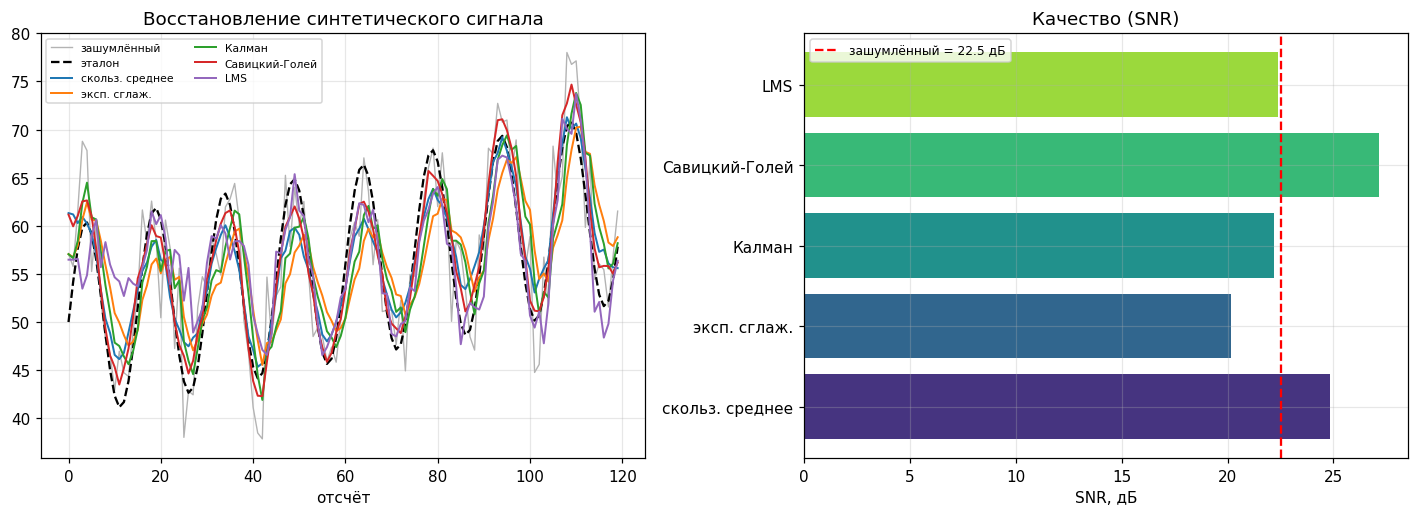

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
ax.plot(t, noisy, color="0.7", lw=0.9, label="зашумлённый")
ax.plot(t, clean, "k--", lw=1.5, label="эталон")
for nm, f in bench.items():
    ax.plot(t, f, lw=1.3, label=nm)
ax.set_xlabel("отсчёт"); ax.legend(ncol=2, fontsize=7)
ax.set_title("Восстановление синтетического сигнала")

names = list(bench.keys())
snrs = [snr_db(clean, bench[n]) for n in names]
ax2 = axes[1]
ax2.barh(names, snrs, color=plt.cm.viridis(np.linspace(0.15, 0.85, len(names))))
ax2.axvline(snr_db(clean, noisy), color="red", ls="--",
            label=f"зашумлённый = {snr_db(clean, noisy):.1f} дБ")
ax2.set_xlabel("SNR, дБ"); ax2.legend(fontsize=8); ax2.set_title("Качество (SNR)")
fig.tight_layout(); plt.show()

## Задача 3. Анализ данных

### Периодичность

Период я искал двумя способами: по автокорреляции и по периодограмме (спектру
через FFT). Если в ряду есть цикл, на ACF будет пик на соответствующем лаге, а
в спектре — пик на соответствующем периоде.

In [14]:
acf = autocorrelation(x, max_lag=25)
period_fft, freqs, power = dominant_period(x)
period_acf = acf_period(acf)
print("Период по ACF:", period_acf)
print("Период по спектру (дней):", round(period_fft, 2))

Период по ACF: 3
Период по спектру (дней): 2.78


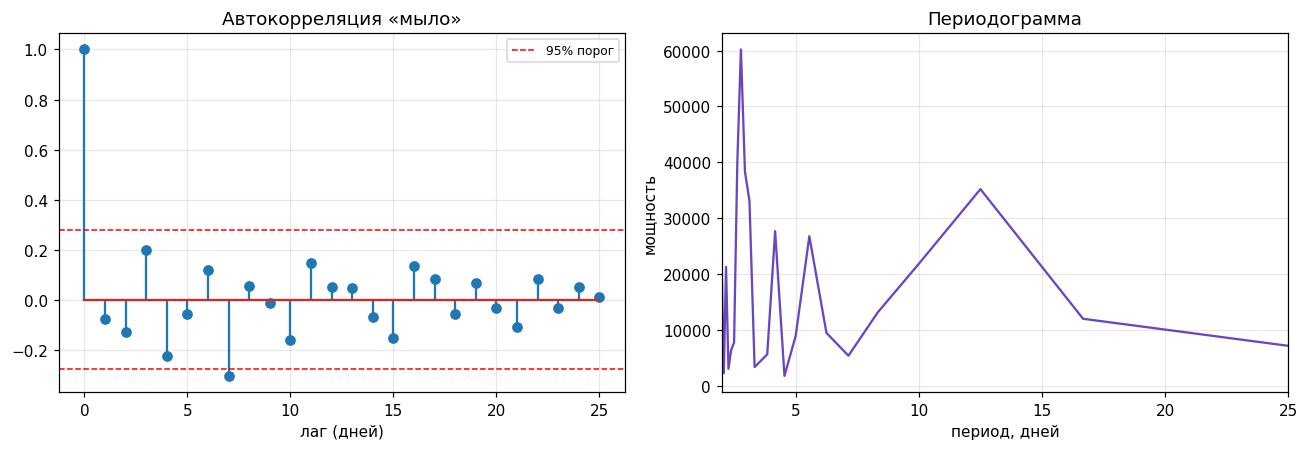

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].stem(range(len(acf)), acf)
ci = 1.96 / np.sqrt(len(x))
axes[0].axhline(ci, color="red", ls="--", lw=1, label="95% порог")
axes[0].axhline(-ci, color="red", ls="--", lw=1)
axes[0].set_xlabel("лаг (дней)"); axes[0].legend(fontsize=8)
axes[0].set_title(f"Автокорреляция «{TARGET}»")

periods = np.full_like(freqs, np.nan)
periods[1:] = 1.0 / freqs[1:]
axes[1].plot(periods[1:], power[1:], color="#6b46c1")
axes[1].set_xlim(2, len(x) // 2)
axes[1].set_xlabel("период, дней"); axes[1].set_ylabel("мощность")
axes[1].set_title("Периодограмма")
fig.tight_layout(); plt.show()

Автокорреляция почти не выходит за порог значимости, и в спектре нет одного
явного пика. То есть выраженной периодичности (например недельной) у ряда нет —
он близок к шуму вокруг среднего.

### Корреляции

Посчитал матрицу корреляций между всеми рядами варианта.

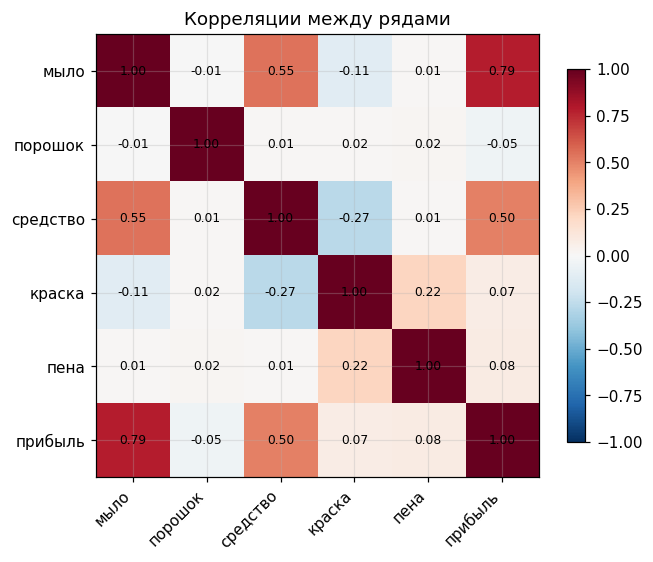

Корреляция товаров с прибылью:
прибыль     1.000
мыло        0.786
средство    0.500
пена        0.079
краска      0.071
порошок    -0.047


In [16]:
corr = correlation_matrix(data)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(PRODUCTS))); ax.set_yticks(range(len(PRODUCTS)))
ax.set_xticklabels(PRODUCTS, rotation=45, ha="right")
ax.set_yticklabels(PRODUCTS)
for i in range(len(PRODUCTS)):
    for j in range(len(PRODUCTS)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Корреляции между рядами")
fig.colorbar(im, ax=ax, shrink=0.8); plt.show()

print("Корреляция товаров с прибылью:")
print(corr["прибыль"].sort_values(ascending=False).round(3).to_string())

Прибыль сильнее всего связана с продажами «мыла» и «средства», а с
остальными товарами связи почти нет. Похоже, что прибыль в основном
складывается из продаж этих позиций.

### Взаимная корреляция товара и прибыли

Проверил, есть ли сдвиг по времени между продажами и прибылью.

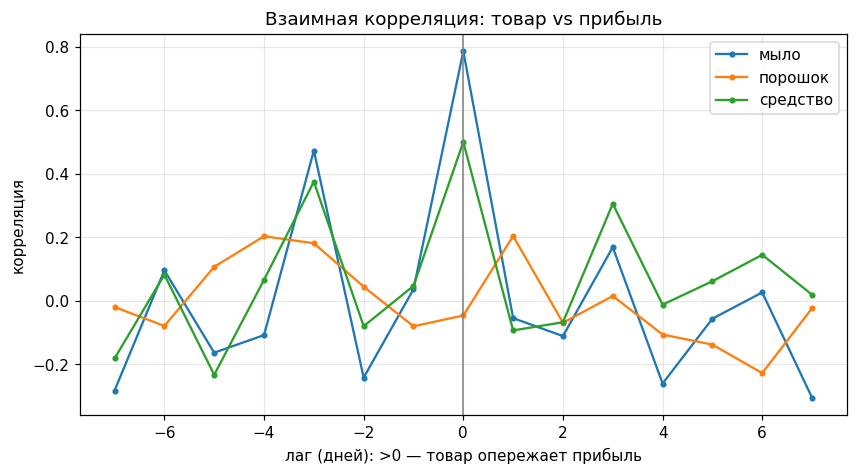

In [17]:
lags = np.arange(-7, 8)
fig, ax = plt.subplots(figsize=(9, 4.5))
for prod in ["мыло", "порошок", "средство"]:
    xc = cross_correlation(data[prod].values, data["прибыль"].values, max_lag=7)
    ax.plot(lags, xc, marker="o", ms=3, label=prod)
ax.axvline(0, color="0.5", lw=1)
ax.set_xlabel("лаг (дней): >0 — товар опережает прибыль")
ax.set_ylabel("корреляция"); ax.legend()
ax.set_title("Взаимная корреляция: товар vs прибыль")
plt.show()

Максимум приходится на нулевой лаг, значит продажи и прибыль меняются в один
день, без опережения.

## Выводы

По фильтрам:
- На синтетике, где есть эталон, лучший результат по SNR дал Савицкий-Голей: он
  сглаживает шум, но сохраняет форму пиков. Скользящее среднее идёт вторым.
- Калман хорошо работает, когда уровень меняется плавно; на периодике он немного
  запаздывает, если не увеличить q.
- Экспоненциальное сглаживание смотрит только в прошлое, поэтому слегка отстаёт
  по фазе — для онлайна это нормально.
- LMS даёт гладкий результат и подстраивается под данные, но ему нужно время на
  сходимость и аккуратный подбор скорости обучения.

По анализу:
- Ряды товаров близки к шуму вокруг постоянного уровня, чёткого периода нет.
- Прибыль более гладкая и сильно коррелирует с продажами мыла и средства,
  меняется с ними в один день.